In [365]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

ticker=str(input('Enter ticker symbol(example: ^NSEI or ^GSPC):'))
btc = yf.Ticker(ticker)

df = btc.history(period="3y",interval='1d')


Enter ticker symbol(example ^NSEI or ^GSPC):^NSEI


In [366]:
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2023-04-03 00:00:00+05:30,17427.949219,17428.050781,17312.750000,17398.050781,230200,0.0,0.0
2023-04-05 00:00:00+05:30,17422.300781,17570.550781,17402.699219,17557.050781,248300,0.0,0.0
2023-04-06 00:00:00+05:30,17533.849609,17638.699219,17502.849609,17599.150391,242700,0.0,0.0
2023-04-10 00:00:00+05:30,17634.900391,17694.099609,17597.949219,17624.050781,254800,0.0,0.0
2023-04-11 00:00:00+05:30,17704.800781,17748.750000,17655.150391,17722.300781,304300,0.0,0.0
...,...,...,...,...,...,...,...
2026-03-25 00:00:00+05:30,23064.400391,23465.349609,23063.199219,23306.449219,505400,0.0,0.0
2026-03-27 00:00:00+05:30,23173.550781,23186.099609,22804.550781,22819.599609,612600,0.0,0.0
2026-03-30 00:00:00+05:30,22549.650391,22714.099609,22283.849609,22331.400391,698600,0.0,0.0


In [342]:
df.drop(['Dividends','Stock Splits'], axis=1, inplace=True, errors='ignore')

In [343]:
df["return_1"] = df["Close"].pct_change()
#df["return_5"] = df["close"].pct_change(5)
#df["return_10"] = df["close"].pct_change(10)

df["volatility_10"] = df["return_1"].rolling(10).std()
df["volatility_20"] = df["return_1"].rolling(20).std()



In [344]:
windows = [5,10,20,40,60]

for w in windows:
    df[f"momentum_{w}"] = df["Close"] / df["Close"].shift(w) - 1

In [345]:
ma_windows = [5,10,20,50]

for w in ma_windows:
    df[f"ma_{w}"] = df["Close"].rolling(w).mean()

for s in [5,10]:
    for l in [20,50]:
        df[f"ma_signal_{s}_{l}"] = df[f"ma_{s}"] - df[f"ma_{l}"]

In [346]:
windows = [10,20,30]

for w in windows:
    mean = df["Close"].rolling(w).mean()
    std = df["Close"].rolling(w).std()
    df[f"zscore_{w}"] = (df["Close"] - mean) / std

In [347]:
windows = [5,10,20]

for w in windows:
    df[f"volatility_{w}_signal"] = df["return_1"].rolling(w).std()

In [348]:
windows = [5,10,20]

for w in windows:
    avg_vol = df["Volume"].rolling(w).mean()
    df[f"volume_spike_{w}_signal"] = df["Volume"] / avg_vol

In [349]:
df["future_return"] = df["Close"].pct_change().shift(-1)

In [ ]:
df.dropna(inplace=True)
df

In [351]:
signal_scores = {}
signal_cols = [col for col in df.columns if "signal" in col or "momentum" in col or "zscore" in col]

for col in signal_cols:
    if col not in ["close","future_return"]:
        ic = df[col].corr(df["future_return"])
        signal_scores[col] = round(float(ic),3)

In [352]:
a=sorted(signal_scores.items(), key=lambda x: abs(x[1]), reverse=True)
a

[('volume_spike_20_signal', 0.07),
 ('volatility_10_signal', 0.066),
 ('volatility_20_signal', 0.062),
 ('volume_spike_5_signal', 0.061),
 ('volume_spike_10_signal', 0.056),
 ('volatility_5_signal', 0.042),
 ('momentum_10', -0.034),
 ('momentum_5', -0.021),
 ('zscore_30', -0.019),
 ('momentum_60', 0.018),
 ('zscore_20', -0.017),
 ('ma_signal_5_20', -0.013),
 ('ma_signal_10_50', 0.013),
 ('momentum_20', 0.007),
 ('ma_signal_5_50', 0.004),
 ('zscore_10', 0.004),
 ('ma_signal_10_20', -0.002),
 ('momentum_40', -0.001)]

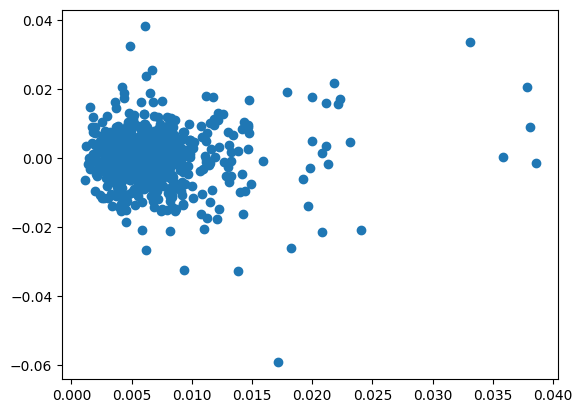

In [353]:
plt.scatter(df['volatility_5_signal'],df['future_return'])
plt.show()

In [354]:
df[signal_cols] = (df[signal_cols] - df[signal_cols].mean()) / df[signal_cols].std()

In [355]:
from sklearn.linear_model import LinearRegression

selected_features = []
for i in a:
  if abs(i[1])>0.03:
    selected_features.append(df[i[0]])

# Stack the selected features into a 2D array where each feature is a column
X = np.column_stack(selected_features)

model = LinearRegression()
y=df['future_return']
model.fit(X, y)

# Get weights (coefficients)
weights = model.coef_
intercept = model.intercept_

print("Weights for a, b, c:", weights)
print("Intercept:", intercept)

Weights for a, b, c: [ 0.00114967  0.00024273  0.0005183   0.00055333 -0.00104399 -0.00030647
 -0.00029734]
Intercept: 0.0002720706949232729


In [357]:
df['alpha']=intercept
for i in range(len(weights)):
  df['alpha'] = df['alpha'] + weights[i]*df[a[i][0]]
  print([a[i][0]])

['volume_spike_20_signal']
['volatility_10_signal']
['volatility_20_signal']
['volume_spike_5_signal']
['volume_spike_10_signal']
['volatility_5_signal']
['momentum_10']


In [358]:
def sharpe_per_trade(trade_returns, trades_per_year, risk_free_rate=0.05):
    """
    trade_returns: list of returns per trade (example: 0.01 = 1%)
    trades_per_year: average number of trades you take per year
    risk_free_rate: annual risk-free rate (default 2%)
    """

    trade_returns = np.array(trade_returns)

    # risk-free per trade
    rf_per_trade = risk_free_rate / trades_per_year

    excess_returns = trade_returns - rf_per_trade

    sharpe = np.sqrt(trades_per_year) * excess_returns.mean() / excess_returns.std(ddof=1)

    return sharpe

In [359]:
total_sum_y1=[]
y1=[]
for i in range(len(df)):
  if df['alpha'].iloc[i]>-1:
    y1.append(df['future_return'].iloc[i])
    total_sum_y1.append(sum(y1))

total_sum_y2=[]
y2=[]
for i in range(len(df)):
  if df['alpha'].iloc[i]>intercept:
    y2.append(df['future_return'].iloc[i])
    total_sum_y2.append(sum(y2))

total return of normal: 18.45% with sharpe of 0.09329456722242976
total return of filtered: 33.06% with sharpe of 0.6171564793677181


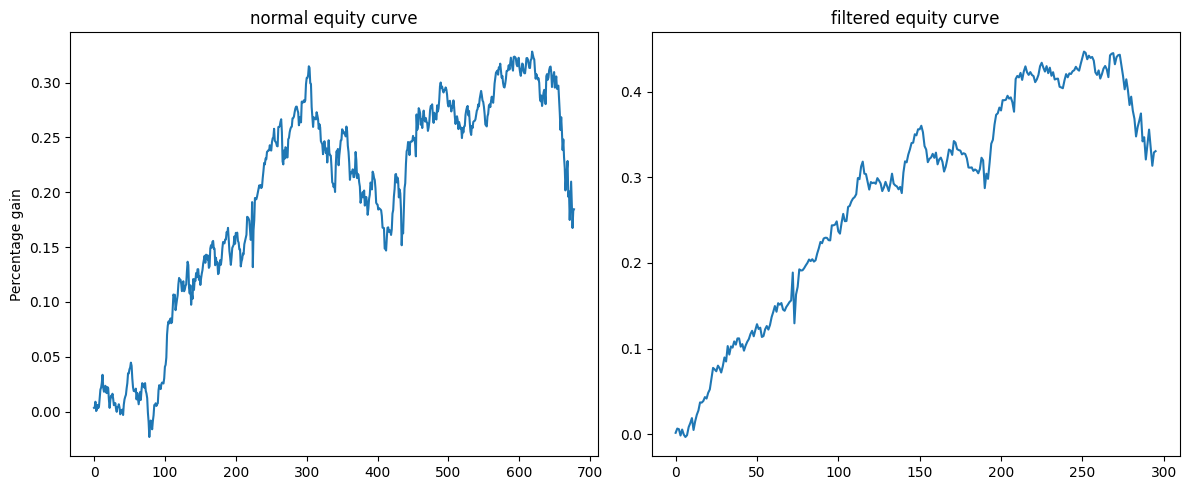

In [363]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # 1 row, 2 columns

s1 = sharpe_per_trade(y1, len(y1)/3)
print(f"total return of normal: {round(total_sum_y1[-1]*100,2)}% with sharpe of {s1}")
axes[0].plot(total_sum_y1)
axes[0].set_title('normal equity curve')
axes[0].set_ylabel('Percentage gain')

s2 = sharpe_per_trade(y2, len(y2)/3 )
print(f"total return of filtered: {round(total_sum_y2[-1]*100,2)}% with sharpe of {s2}")
axes[1].plot(total_sum_y2)
axes[1].set_title('filtered equity curve')
#axes[1].set_ylabel('pct gain')

plt.tight_layout()
plt.show()